# 1. The statistic and the estimated parameters

WDF scores one window of whitened data at a time. This notebook builds such a
window, runs the pieces the search runs, and checks that the number it produces
means what it claims.

Everything here is made in the notebook. There is no data set to download and no
frame file to point at; `pytsa` (p4TSA's compiled core) is the only requirement
beyond the analysis layer.

## A window of whitened noise with a transient in it

The search sees data that conditioning has already whitened, so the noise is
white with standard deviation `sigma`. We inject a sine-Gaussian scaled to a
known matched-filter signal-to-noise ratio, which is the truth we will compare
against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pytsa.tsa import WaveletTransform
from wdf.structures.array2SeqView import array2SeqView
from wdf.mock import waveforms as w

FS, N, SIGMA = 2048.0, 512, 1.0
INJECTED_RHO = 12.0

rng = np.random.default_rng(7)
noise = rng.standard_normal(N) * SIGMA

burst = w.sine_gaussian(200.0, 12.0, int(FS))
signal = np.zeros(N)
n = min(len(burst), N)
start = (N - n) // 2
signal[start:start + n] = burst[:n] / np.linalg.norm(burst[:n]) * INJECTED_RHO

window = noise + signal
print(f"injected rho = {np.linalg.norm(signal) / SIGMA:.2f}")

injected rho = 12.00


## The transform

`pytsa`'s `WaveletTransform` is an orthonormal discrete wavelet transform in
GSL's packed layout. Orthonormal matters: Parseval's theorem then says the
coefficients have the same norm as the samples, which is what makes the
statistic an amplitude on the noise scale rather than a basis-dependent number.

In [2]:
def forward(samples, wave):
    """Wavelet coefficients of one window."""
    view = array2SeqView(0.0, FS, len(samples))
    view = view.Fill(0.0, np.asarray(samples, dtype=float).copy())
    WaveletTransform(len(samples), getattr(WaveletTransform, wave)).Forward(view)
    return np.array([view.GetY(0, i) for i in range(len(samples))])


def inverse(coefficients, wave):
    """Back to the time domain."""
    view = array2SeqView(0.0, FS, len(coefficients))
    view = view.Fill(0.0, np.asarray(coefficients, dtype=float).copy())
    WaveletTransform(len(coefficients), getattr(WaveletTransform, wave)).Inverse(view)
    return np.array([view.GetY(0, i) for i in range(len(coefficients))])


WAVE = "Sym8"
coefficients = forward(window, WAVE)
print(f"||c|| = {np.linalg.norm(coefficients):.6f}")
print(f"||x|| = {np.linalg.norm(window):.6f}   <- Parseval")

||c|| = 23.576783
||x|| = 23.576783   <- Parseval


## Thresholding, and the statistic

Coefficients below the Donoho-Johnstone universal threshold are set to zero. The
rule depends only on the noise scale and the number of coefficients, not on any
assumption about what the signal looks like, which is what keeps the search
un-modelled. The survivors keep their amplitude: this is *hard* thresholding,
because a detection statistic and a parameter estimate are read off the
amplitude, unlike a denoised reconstruction.

What is left is scored by

$$\rho_{\mathrm{WDF}} = \frac{\lVert c \rVert_2}{\sigma}$$

which the trigger files record in the column `EnWDF`.

In [3]:
from wdf.analysis.wavelets import donoho_johnstone_threshold, wavelet_energy_snr

threshold = donoho_johnstone_threshold(SIGMA, N)
kept = np.where(np.abs(coefficients) >= threshold, coefficients, 0.0)

print(f"threshold      {threshold:.3f}")
print(f"survivors      {np.count_nonzero(kept)} of {N}")
print(f"EnWDF          {wavelet_energy_snr(kept, SIGMA)['snr']:.3f}")

reconstruction = inverse(kept, WAVE)
print(f"||x_hat||/sigma {np.linalg.norm(reconstruction) / SIGMA:.3f}   <- the same number")

threshold      3.532
survivors      3 of 512
EnWDF          9.321
||x_hat||/sigma 9.321   <- the same number


The recovered value is below the injected 12: thresholding throws away the part
of the signal that fell below the noise floor coefficient by coefficient. That
loss is real and is what the efficiency curves in a review notebook measure.

## Basis competition

Each window is transformed in every candidate basis and scored in each. The
basis that concentrates the transient best wins, and it is the one recorded on
the trigger. A different transient, or a different noise realisation, picks a
different winner -- which is the point of carrying more than one basis.

In [4]:
CANDIDATE_BASES = ["Haar", "DaubC4", "DaubC8", "DaubC12", "DaubC16", "DaubC20",
                   "Sym4", "Sym8", "Coif1", "Coif2"]

scores = {}
for name in CANDIDATE_BASES:
    c = forward(window, name)
    survivors = np.where(np.abs(c) >= donoho_johnstone_threshold(SIGMA, N), c, 0.0)
    scores[name] = wavelet_energy_snr(survivors, SIGMA)["snr"]

for name, value in sorted(scores.items(), key=lambda kv: -kv[1]):
    bar = "#" * int(round(value * 3))
    print(f"  {name:8s} {value:6.2f}  {bar}")

  Sym8       9.32  ############################
  DaubC20    9.12  ###########################
  DaubC16    8.99  ###########################
  Sym4       8.37  #########################
  DaubC4     8.25  #########################
  DaubC8     8.20  #########################
  Coif2      8.04  ########################
  DaubC12    7.98  ########################
  Coif1      6.48  ###################
  Haar       5.25  ################


## The estimated parameters

`extract_meta_features` is what the parameter-estimation observer calls on every
trigger. It takes the reconstruction and the coefficients, and returns the
quantities the trigger files carry.

The three amplitude-like numbers are all on the same noise scale:

    snrPeak = max|x| / sigma
    snrMean = rms of x over its own support / sigma
    EnWDF   = ||x|| / sigma

so `EnWDF` grows as the square root of the number of samples the transient
occupies, while the other two do not. They are ordered by construction.

In [5]:
from wdf.observers.ParameterEstimationObserver import extract_meta_features

(tPeak, duration, freqMin, freqMean, freqMax, freqPeak,
 snrMean, snrPeak) = extract_meta_features(
    reconstruction, fs=FS, sigma=SIGMA, wt=kept, f_low=10.0)

enwdf = np.linalg.norm(reconstruction) / SIGMA

injected_peak = float(np.argmax(np.abs(signal))) / FS
print(f"tPeak     {tPeak * 1e3:7.1f} ms   (injected peak at {injected_peak * 1e3:.1f} ms)")
print(f"duration  {duration * 1e3:7.1f} ms")
print(f"freqPeak  {freqPeak:7.1f} Hz   (injected 200 Hz)")
print(f"freqMean  {freqMean:7.1f} Hz")
print(f"band      [{freqMin:.0f}, {freqMax:.0f}] Hz")
print()
print(f"snrMean {snrMean:.2f}  <=  snrPeak {snrPeak:.2f}  <=  EnWDF {enwdf:.2f}")

tPeak       123.0 ms   (injected peak at 123.0 ms)
duration     18.6 ms
freqPeak    181.0 Hz   (injected 200 Hz)
freqMean    199.3 Hz
band      [164, 300] Hz

snrMean 1.45  <=  snrPeak 3.05  <=  EnWDF 9.32


`freqPeak` comes from the wavelet plane: it is the band of the largest surviving
coefficient, the tile where the local signal-to-noise ratio peaks. That band is
an octave wide, so for a narrowband burst `freqPeak` lands on the geometric
centre of the octave containing the true frequency (here 181 Hz for the octave
128-256 Hz) rather than on the frequency itself. `freqMean`, a spectral moment
of the reconstruction, is the sharper estimate for a narrowband signal.

The trade is deliberate. For a transient that sweeps in frequency, the maximum
of the spectrum is where the signal spends the most *time*, which is not where
it is loudest; the loudest tile is. The next notebook shows that case.

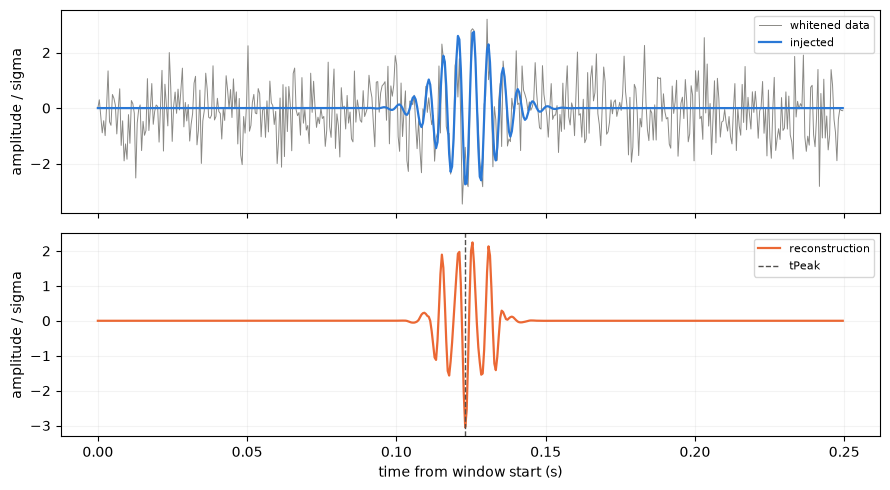

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
t = np.arange(N) / FS

axes[0].plot(t, window, lw=0.7, color="#8a8985", label="whitened data")
axes[0].plot(t, signal, lw=1.6, color="#2a78d6", label="injected")
axes[0].legend(fontsize=8)
axes[0].set_ylabel("amplitude / sigma")

axes[1].plot(t, reconstruction, lw=1.6, color="#eb6834", label="reconstruction")
axes[1].axvline(tPeak, color="#52514e", ls="--", lw=1, label="tPeak")
axes[1].legend(fontsize=8)
axes[1].set_xlabel("time from window start (s)")
axes[1].set_ylabel("amplitude / sigma")

for ax in axes:
    ax.grid(alpha=0.15)
fig.tight_layout()
plt.show()